<a href="https://colab.research.google.com/github/ebritolbv-cmd/BrazilQuantumCamp/blob/main/colab_A6_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INTRODUÇÃO PRÁTICA A REDES NEURAIS QUÂNTICAS III


Nesta aula vamos treinar modelos para prever uma variável binária:

y = 1 → Alto risco de ficar no vermelho

y = 0 → Baixo risco

Aqui, vamos comparar uma MLP (Rede Neural Clássica) com uma QNN (Rede Neural Quântica). A ideia central é que ambos recebem as mesmas entradas e são treinados com a mesma função de custo (BCE). O objetivo é entender como preparar dados, treinar o modelo, como fazer inferêncai com o modelo, e como avaliar o modelo (accuracy e matriz de confusão)

# Instalação
Se estiver no Colab, precisamos instalar PennyLane e dependências.
Em ambiente local, normalmente isso já está instalado via pip/conda

In [ ]:
# Se estiver no Colab, rode:
!pip -q install pennylane torch scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 83.1 MB/s eta 0:00:00


# Imports

NumPy: gerar e manipular dados numéricos.

PyTorch: definir modelos (MLP e QNN), treinar com backprop e otimização (Adam).

scikit-learn: split treino/teste, normalização (StandardScaler), métricas e matriz de confusão.

matplotlib: plotar loss e matrizes de confusão.

PennyLane: construir o circuito quântico e integrá-lo como camada do PyTorch.

In [ ]:
# ============================================================
# AULA PRÁTICA (2h): Finanças pessoais
# Tarefa: prever "RISCO DE FICAR NO VERMELHO" (0/1)
# Comparação: MLP (clássico) vs QNN (PennyLane)
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import pennylane as qml

# 1. Geração de dados

Aqui construímos um dataset sintético com 5 variáveis (features) típicas:

- x0 = renda

- x1 = gastos_totais / renda

- x2 = cartão / renda

- x3 = dívida / renda

- x4 = reserva / renda

A saída y é gerada por uma regra probabilística:

- risco aumenta com gastos altos + dívida alta + cartão alto

- risco diminui com reserva alta

- adicionamos ruído para parecer “vida real” (dados não-perfeitos)


In [ ]:
# ------------------------------------------------------------
# 1) Dados (simulados, mas com cara de finanças reais)
# ------------------------------------------------------------
np.random.seed(0)
torch.manual_seed(0)

def make_data(N=2000):
    """
    Features (todas normalizadas depois):
      x0 = renda (R$)
      x1 = gastos_totais / renda
      x2 = cartao / renda
      x3 = divida / renda
      x4 = reserva / renda

    Label:
      y=1 (risco alto) se gastos altos + dívida alta + reserva baixa.
    """

    renda = np.random.lognormal(mean=np.log(3000), sigma=0.4, size=N)

    gastos_ratio  = np.random.uniform(0.5, 1.05, size=N)   # pode passar de 1 => risco
    cartao_ratio  = np.random.uniform(0.05, 0.6, size=N)
    divida_ratio  = np.random.uniform(0.0, 2.0, size=N)
    reserva_ratio = np.random.uniform(0.0, 2.0, size=N)

    # "Score" de risco (regra simples)
    score = (
        6.0*(gastos_ratio - 0.85)
        + 1.2*(divida_ratio - 0.8)
        + 0.8*(cartao_ratio - 0.25)
        - 0.7*(reserva_ratio - 0.5)
        + np.random.normal(0, 0.4, size=N)  # ruído (vida real)
    )

    prob = 1/(1+np.exp(-score))
    y = (prob > 0.5).astype(int)

    X = np.column_stack([renda, gastos_ratio, cartao_ratio, divida_ratio, reserva_ratio])
    return X, y

X, y = make_data(N=2500)

# 2. Split e normalização
Depois de gerar os dados:

- train_test_split separa treino e teste (mantendo a proporção de classes com stratify=y)

- StandardScaler padroniza as features:

$x' = \frac{x-\mu}{\sigma}$
	​


Isso ajuda muito no treino, porque:

- evita escalas muito diferentes (ex.: renda em milhares vs razões em 0–2)

- melhora estabilidade numérica e convergência (Adam aprende melhor)

Por fim, convertemos tudo para torch.tensor, porque PyTorch só treina com tensores.

In [ ]:
# split
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)

# normaliza
scaler = StandardScaler()
Xtr = scaler.fit_transform(Xtr)
Xte = scaler.transform(Xte)

# torch
Xtr = torch.tensor(Xtr, dtype=torch.float32)
ytr = torch.tensor(ytr, dtype=torch.float32).view(-1, 1)
Xte = torch.tensor(Xte, dtype=torch.float32)
yte = torch.tensor(yte, dtype=torch.float32).view(-1, 1)



Mostra a fração de exemplos com y=1.

Isso importa porque:

- se for muito desbalanceado (ex.: 95% zeros), accuracy pode enganar

- matriz de confusão ajuda a ver se o modelo erra “sempre na mesma classe”

In [ ]:
print("Taxa de 'risco alto' no dataset:", float(y.mean()))

Taxa de 'risco alto' no dataset: 0.3492


# 3. Modelo Clássico: MLP

A MLP é um classificador com camadas densas:

- Entrada: 5 features

- Camada escondida: 16 neurônios + ReLU

- Saída: 1 neurônio (um logit)

Logit é o valor “antes da sigmoid”.
A probabilidade é:

$p(y=1|x) = \sigma(logit) = \frac{1}{1+e^{-logit}}$


Aqui, vamos usar BCEWithLogitsLoss, que já combina sigmoid + BCE de forma estável numericamente, por isso não vamos usar a probablidade.

In [ ]:
# ------------------------------------------------------------
# 2) Modelo clássico (MLP bem simples)
# ------------------------------------------------------------
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 16),
            nn.ReLU(),
            nn.Linear(16, 1)  # logit
        )
    def forward(self, x):
        return self.net(x)

# 4. Modelo Quântico: QNN

A rede quântica vai ser construída assim:

- pré-processamento clássico: Linear(5 -> n_qubits), que transforma 5 features em n_qubits valores que vão virar ângulos

- feature map (encoding): AngleEmbedding(..., rotation="Y"), que codifica cada entrada $x_i$ com rotação $R_y(x_i)$ em um qubit.


- ansatz variacional: StronglyEntanglingLayers(weights), que são as camadas parametrizadas que geram um estado quântico expressivo. Os pesos têm shape (L,n_qubits,3) porque cada qubit recebe 3 rotações por camada

- medida: ⟨$𝑍_0$⟩ retorna um número real entre [−1,1], isso funciona como “feature quântica” para a parte final clássica

- camada final clássica: Linear(1 -> 1), que transforma a saída quântica em logit

In [ ]:
# ------------------------------------------------------------
# 3) Modelo quântico (PennyLane) — StronglyEntanglingLayers
#    - 5 qubits
#    - encoding por AngleEmbedding
#    - ansatz: StronglyEntanglingLayers (n_layers camadas)
# ------------------------------------------------------------
n_qubits = 4
n_layers = 3

dev = qml.device("default.qubit", wires=n_qubits)

def feature_map(inputs):
    # inputs tem 5 valores -> um por qubit
    qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation="Y")

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def qnode(inputs, weights):
    """
    inputs: (n_qubits,) vindo do pré-processamento clássico
    weights: parâmetros do StronglyEntanglingLayers
             shape (n_layers, n_qubits, 3)
    """
    feature_map(inputs)
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

# StronglyEntanglingLayers usa weights com shape (L, n_qubits, 3)
quantum_layer = qml.qnn.TorchLayer(
    qnode,
    weight_shapes={"weights": (n_layers, n_qubits, 3)}
)

class QNN(nn.Module):
    """
    Modelo híbrido mínimo:
      5 features -> camada linear -> 5 valores -> circuito -> logit
    """
    def __init__(self, n_qubits):
        super().__init__()
        self.pre = nn.Linear(5, n_qubits)   # aqui fica 5 -> 5 pra casar com 5 qubits
        self.q = quantum_layer
        self.post = nn.Linear(1, 1)  # expval -> logit final

    def forward(self, x):
        xq = torch.tanh(self.pre(x))     # controla escala do input do circuito
        qout = self.q(xq).view(-1, 1)    # saída do circuito
        return self.post(qout)


# 5. Treino com BCEWIthLogitsLoss + Adam, e Análise

A função train(model) faz:

- logits = model(Xtr)

- loss = BCEWithLogitsLoss(logits, ytr)

- loss.backward() computa gradientes

- opt.step() atualiza parâmetros

Importante: não usamos sigmoid dentro do modelo.
A sigmoid aparece só na avaliação (para converter logit em probabilidade).

In [ ]:
# ------------------------------------------------------------
# 4) Treino (função única para os dois modelos)
# ------------------------------------------------------------
def train(model, epochs=50, lr=0.01):
    loss_fn = nn.BCEWithLogitsLoss()
    opt = optim.Adam(model.parameters(), lr=lr)

    losses = []
    for ep in range(epochs):
        model.train()
        opt.zero_grad()
        logits = model(Xtr)
        loss = loss_fn(logits, ytr)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses

@torch.no_grad()
def test_accuracy(model):
    model.eval()
    probs = torch.sigmoid(model(Xte))
    preds = (probs >= 0.5).float()
    acc = (preds.eq(yte)).float().mean().item()
    return acc, preds.cpu().numpy().astype(int).flatten()

In [ ]:
# ------------------------------------------------------------
# 5) Rodar: MLP vs QNN
# ------------------------------------------------------------
mlp = MLP()
qnn = QNN(n_qubits)

loss_mlp = train(mlp, epochs=50, lr=0.1)
loss_qnn = train(qnn, epochs=50, lr=0.1)

acc_mlp, pred_mlp = test_accuracy(mlp)
acc_qnn, pred_qnn = test_accuracy(qnn)

n_params = [count_parameters(mlp), count_parameters(qnn)]

print("\nAccuracy (teste):")
print("MLP:", acc_mlp)
print("QNN:", acc_qnn)
print("\nParâmetros treináveis:")
print("MLP:", n_params[0])
print("QNN:", n_params[1])


Accuracy (teste):
MLP: 0.9151999950408936
QNN: 0.91839998960495

Parâmetros treináveis:
MLP: 113
QNN: 62


## 5.1. Loss vs Epoch

O gráfico mostra a convergência:

- Se a loss cai rápido → otimização “fácil”

- Se oscila muito ou cai lentamente → landscape difícil / ruído de gradiente / saturação

Comparar as curvas ajuda a discutir:

- estabilidade do treino

- taxa de aprendizado

- saturação de tanh no pré-processamento

- dificuldade típica de otimização em QNN

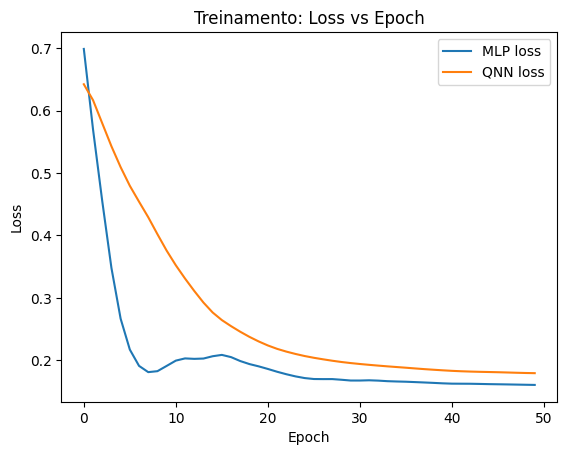

In [ ]:
# ------------------------------------------------------------
# 6) Gráfico de loss
# ------------------------------------------------------------
plt.figure()
plt.plot(loss_mlp, label="MLP loss")
plt.plot(loss_qnn, label="QNN loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Treinamento: Loss vs Epoch")
plt.show()

## 5.2. Matriz de confusão: onde o modelo erra?

A matriz de confusão separa os erros por classe:

- TP: acertou risco alto (1)

- TN: acertou risco baixo (0)

- FP: falso alarme (pred 1 mas era 0)

- FN: deixou passar risco alto (pred 0 mas era 1)

Em finanças pessoais, normalmente FN é o pior (não detectar alto risco).

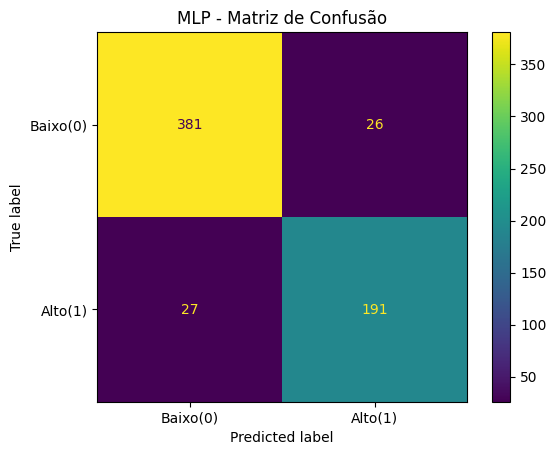

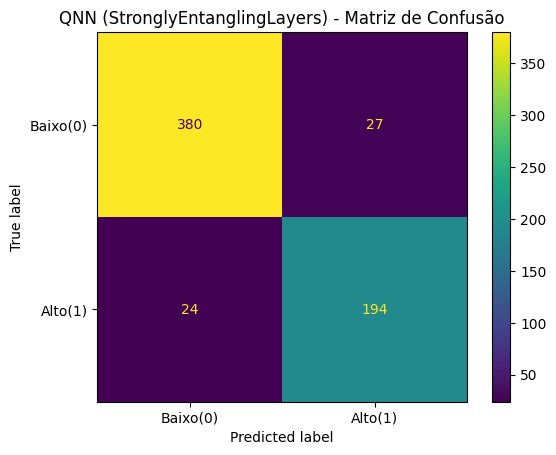

In [ ]:
# ------------------------------------------------------------
# 7) Matriz de confusão
# ------------------------------------------------------------
y_true = yte.cpu().numpy().astype(int).flatten()

cm1 = confusion_matrix(y_true, pred_mlp)
cm2 = confusion_matrix(y_true, pred_qnn)

disp1 = ConfusionMatrixDisplay(cm1, display_labels=["Baixo(0)", "Alto(1)"])
disp2 = ConfusionMatrixDisplay(cm2, display_labels=["Baixo(0)", "Alto(1)"])

disp1.plot()
plt.title("MLP - Matriz de Confusão")
plt.show()

disp2.plot()
plt.title("QNN (StronglyEntanglingLayers) - Matriz de Confusão")
plt.show()

## 5.3. Teste com perfil manual

A função predict_risk(...) faz o pipeline completo:

- monta um vetor com as 5 features

- aplica o mesmo scaler.transform

- passa no modelo

- aplica sigmoid → probabilidade final de risco alto

- Isso é essencial para a aula porque conecta o modelo à “vida real”:

In [ ]:
# ------------------------------------------------------------
# 8) Extra: testar um "perfil" manual
# ------------------------------------------------------------
@torch.no_grad()
def predict_risk(model, renda, gastos_ratio, cartao_ratio, divida_ratio, reserva_ratio):
    x = np.array([[renda, gastos_ratio, cartao_ratio, divida_ratio, reserva_ratio]], dtype=float)
    x = scaler.transform(x)
    xt = torch.tensor(x, dtype=torch.float32)
    p = torch.sigmoid(model(xt)).item()
    return p

print("\nExemplo rápido:")
p = predict_risk(qnn, renda=1000, gastos_ratio=0.6, cartao_ratio=0.40, divida_ratio=1.5, reserva_ratio=0.1)
print(f"Probabilidade de risco alto (QNN): {p:.3f}")



Exemplo rápido:
Probabilidade de risco alto (QNN): 0.247
